# Lopez-Salido, Stein & Zakrajšek (2017): Aaa-Spread Extension
## Introduction

`02_replication.ipynb` asked whether our code reproduces Lopez-Salido, Stein
& Zakrajšek (2017, "LSZ") and whether their result holds up on more recent
data. This notebook asks a different question: **does the paper's specific
choice of credit spread matter?**

LSZ build their credit-market-sentiment measure from the spread between
Baa-rated corporate bonds and the 10-year Treasury. Baa is the lowest
investment-grade rating - one downgrade away from "junk." That is not an
arbitrary choice. The paper's whole mechanism is about reach-for-yield
behavior: investors bidding up prices (narrowing spreads) on the riskiest
bonds that are still investment grade, and that optimism unwinding two years
later. If that story is right, a spread built from Aaa-rated bonds (the
highest and safest investment-grade tier, economically much closer to a
riskless Treasury than to a junk bond) should carry much less of that
signal. Aaa issuers are about as far from the reach-for-yield segment of the
market as a corporate borrower can be.

This notebook rebuilds every exhibit from `02_replication.ipynb`, holding
every other part of the construction fixed (same data windows, same
controls, same methodology) and swapping only `BAA_Treasury_spread` for
`AAA_Treasury_spread`. This is exactly what the `spread_col` argument in
every `replicate_*.py` module is for. The question we're really asking:
**does the paper's identification survive using a spread that carries much
less credit-risk information, or does it need Baa specifically?**

## Comparison

Every exhibit below is shown **Baa vs. Aaa, side by side**, for both the
1929-2015 replication window and the 1929-2025 extended window — the
opposite framing from `02_replication.ipynb`, which fixed the spread (Baa)
and compared windows.

## Setup

Same four `replicate_*` modules as `02_replication.ipynb`. Every one of
their `build_panel` / `plot_figure_*` functions takes a `spread_col`
argument - that's the whole mechanism this notebook exercises.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

sys.path.insert(0, str(Path.cwd().parent / "src"))

import replicate_figure_1 as f1
import replicate_figure_2 as f2
import replicate_table_1 as t1
import replicate_table_2 as t2
from plot_style import (
    RECESSION_COLOR,
    recession_spans,
    set_paper_style,
    style_axes,
)
from settings import config

PROCESSED_DATA_DIR = Path(config("PROCESSED_DATA_DIR"))
OUTPUT_DIR = Path(config("OUTPUT_DIR"))

REP_START, REP_END, EXT_END = t1.REP_START, t1.REP_END, t1.EXT_END
BAA, AAA = "BAA_Treasury_spread", "AAA_Treasury_spread"
print(
    f"Replication window: {REP_START}-{REP_END}  \nExtended window: {REP_START}-{EXT_END}"
)


def show_tex(path):
    """The raw LaTeX `emit`/`emit_table_2` write to `_output/` -- exactly
    what feeds `reports/report.tex` -- as a syntax-highlighted, collapsed-
    by-default code block, so it's available without competing with the
    rendered table displayed above it."""
    display(
        Markdown(
            f"<details><summary>Raw LaTeX written to <code>{path.name}</code></summary>\n\n"
            f"```latex\n{path.read_text()}\n```\n</details>"
        )
    )

Replication window: 1929-2015  
Extended window: 1929-2025


A first, purely descriptive look at the two spreads sets up everything that
follows: same underlying market (corporate bonds vs. Treasuries), very
different behavior.

In [2]:
monthly = pd.read_parquet(PROCESSED_DATA_DIR / "fred_final_series_monthly.parquet")
window = monthly.loc[(monthly.index >= f1.BUFFER_START) & (monthly.index <= f1.REP_END)]
baa_level, aaa_level = window[BAA].dropna(), window[AAA].dropna()

stats = pd.DataFrame({"Baa": baa_level.describe(), "Aaa": aaa_level.describe()})
display(stats.style.format("{:.2f}"))
print(f"Correlation of levels: {baa_level.corr(aaa_level):.2f}")
print(f"Correlation of monthly changes: {baa_level.diff().corr(aaa_level.diff()):.2f}")

,Baa,Aaa
count,1092.00,1092.00
mean,1.97,0.84
std,0.99,0.54
min,0.29,-0.17
25%,1.15,0.36
50%,1.90,0.76
75%,2.51,1.20
max,7.24,2.68


Correlation of levels: 0.74
Correlation of monthly changes: 0.69


Aaa runs at roughly 42% of Baa's average level (0.84pp vs. 1.97pp) and about
55% of its volatility (std. 0.54 vs. 0.99).
Aaa corporate yields also occasionally dip just below the 10-year Treasury yield,
a well-known quirk that simply cannot happen to Baa. The two series are
correlated (0.74 in levels, 0.69 in monthly changes) but far
from identical. That gap is the whole story this notebook investigates.

## Figure I: Baa vs. Aaa Credit Spread

`replicate_figure_1.plot_figure_1` takes a `spread_col` argument specifically
so it can render either spread; `replicate_figure_1.SPREAD_VARIANTS` is the
`(label, column)` list `main()` loops over to emit both `figure_1_*.pdf` and
`figure_1_aaa_*.pdf`. We call it directly on both columns.

Baa-Treasury spread


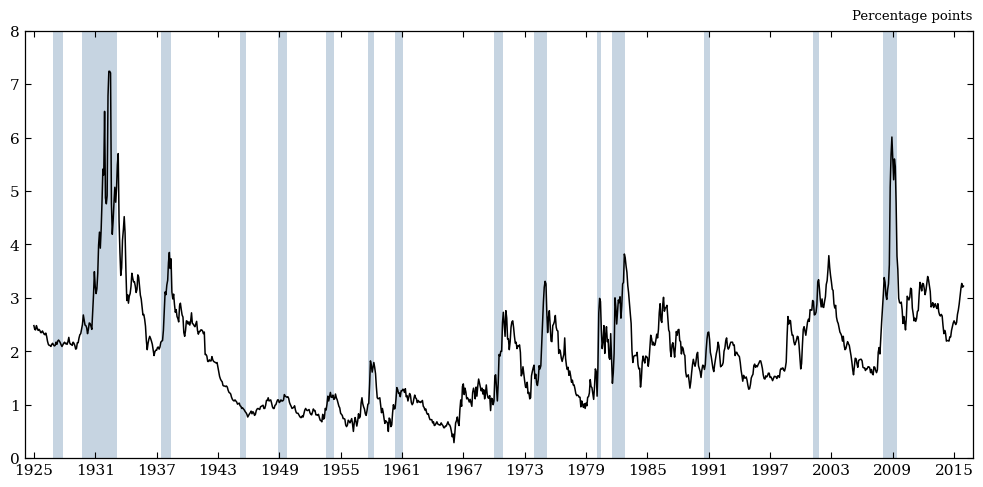

AAA-Treasury spread


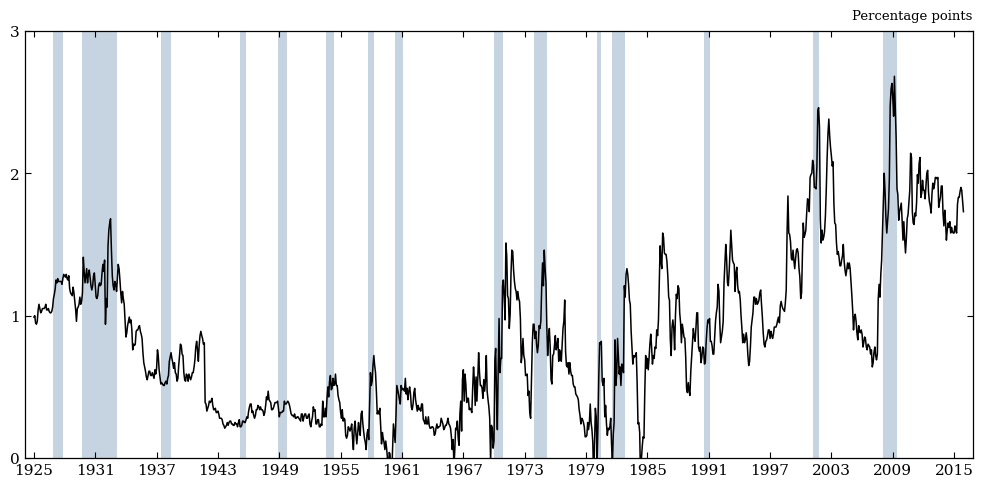

In [3]:
fig_baa, spread_baa = f1.plot_figure_1(
    monthly, f1.BUFFER_START, f1.REP_END, spread_col=BAA
)
print("Baa-Treasury spread")
plt.show()
fig_aaa, spread_aaa = f1.plot_figure_1(
    monthly, f1.BUFFER_START, f1.REP_END, spread_col=AAA
)
print("AAA-Treasury spread")
plt.show()

Two things jump out immediately. First, the y-axis itself is different -
`plot_figure_1` scales its ticks to the data, and Aaa's own maximum (2.68pp)
is barely a third of Baa's (7.24pp), so matplotlib draws a 0-3pp axis for
Aaa against Baa's 0-8pp. Second, and more importantly, **the depression
barely shows up in Aaa**: where Baa spiked past 7pp in 1932-33, Aaa peaks at
just 1.7pp over the same months. Aaa bondholders were largely insulated from
the credit panic that Baa investors lived through.

Beyond the Depression, the Aaa's shape is qualitatively different from Baa's,
not just smaller. It shows a slow, decades-long structural climb from the
1960s trough (near 0.2pp) up to a local peak around 2000-03 and again
2008-09 (~2.4-2.7pp) that looks much more like a slow-moving trend than a
series of sharp business-cycle spikes, and it sits at or near zero for
extended stretches (the early 1960s, the late 1970s) where Baa never comes
close to zero. A direct
overlay makes both the amplitude gap and the shape difference easy to see
side by side:

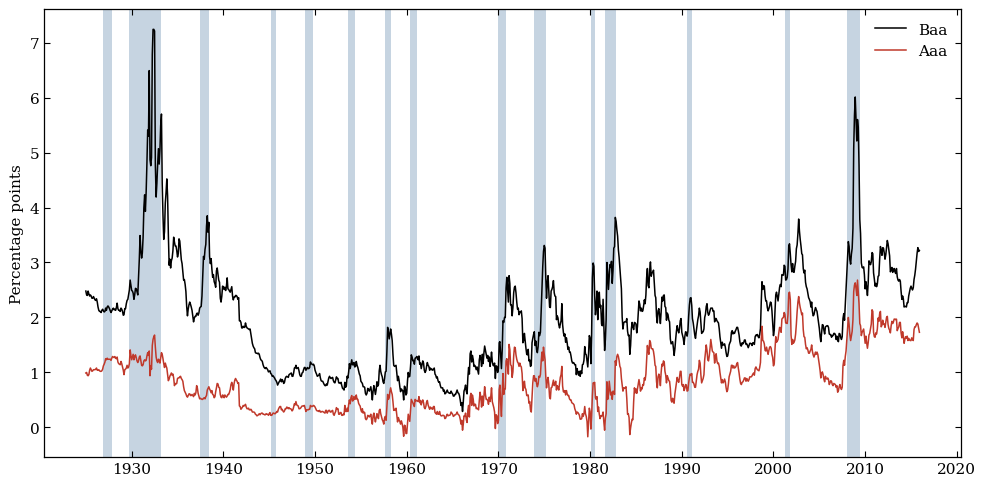

In [4]:
set_paper_style()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(spread_baa.index, spread_baa.values, color="black", lw=1.1, label="Baa")
ax.plot(spread_aaa.index, spread_aaa.values, color="#c0392b", lw=1.1, label="Aaa")
for s, e in recession_spans(window):
    ax.axvspan(s, e, color=RECESSION_COLOR, lw=0)
ax.set_ylabel("Percentage points")
ax.legend(loc="upper right", frameon=False)
style_axes(ax)
fig.tight_layout()
plt.show()

### Extended Window

Pushing both spreads through 2025 continues to show the difference in the magnitude of the spread.

Baa-Treasury spread


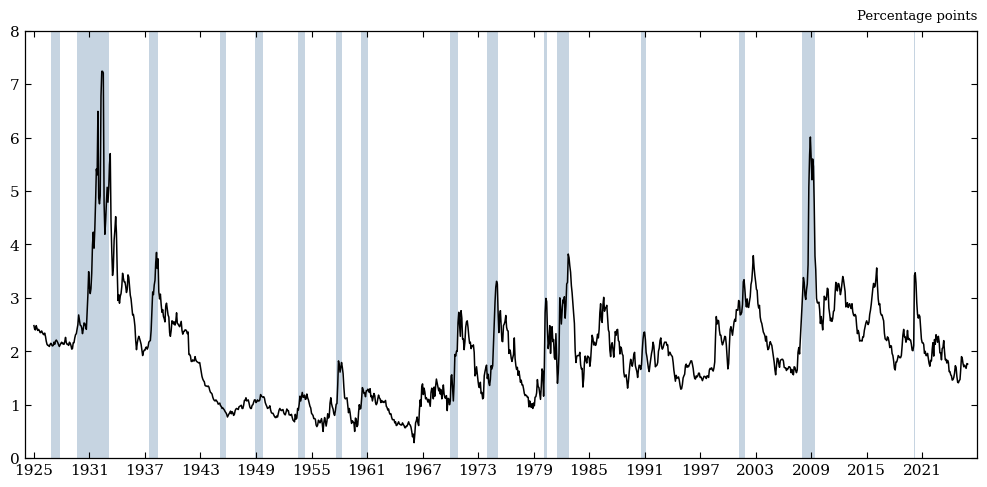

AAA-Treasury spread


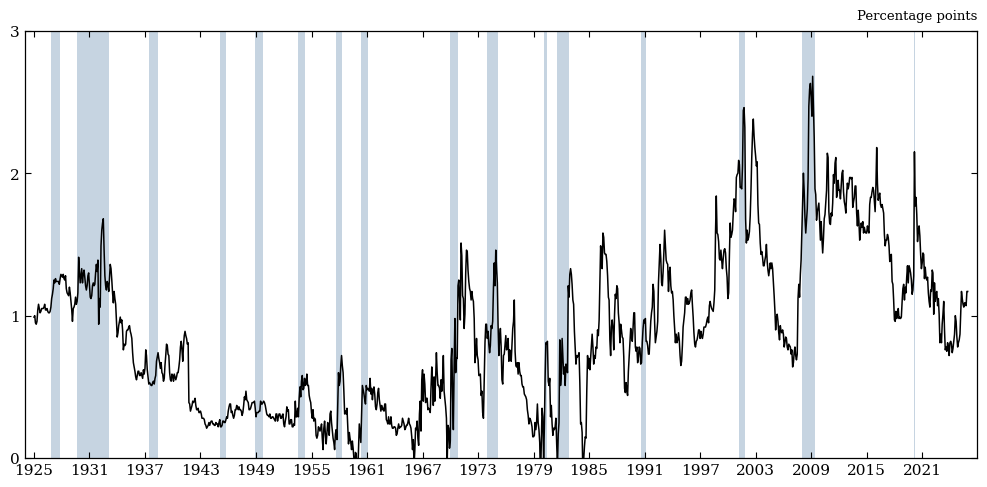

In [5]:
fig_baa_e, spread_baa_e = f1.plot_figure_1(
    monthly, f1.BUFFER_START, f1.EXT_END, spread_col=BAA
)
print("Baa-Treasury spread")
plt.show()
fig_aaa_e, spread_aaa_e = f1.plot_figure_1(
    monthly, f1.BUFFER_START, f1.EXT_END, spread_col=AAA
)
print("AAA-Treasury spread")
plt.show()

## Table I: Baa vs. Aaa as Growth Predictors

### Definitions

| Code column | Paper symbol | Definition |
|---|---|---|
| `dy_next` (dependent variable) | $\Delta y_t$ | Log-difference of real GDP per capita, year $t-1$ to $t$ |
| `d_credit_spread` | $\Delta s_{t-1}$ | Change in the credit spread over year $t-1$ — **Baa-Treasury** in `df1_baa`, **Aaa-Treasury** in `df1_aaa` |
| `sp_return` | $r_{t-1}^{SP}$ | S&P 500 total (price + dividend) log return over year $t-1$ (identical in both panels) |
| `gdp_pc_growth` | $\Delta y_{t-1}$ | Lagged control: real GDP-per-capita growth over year $t-1$ |
| `d_treasury_3mo` | $\Delta i_{t-1}^{(3m)}$ | Change in the 3-month Treasury yield over year $t-1$ |
| `d_treasury_10yr` | $\Delta i_{t-1}^{(10y)}$ | Change in the 10-year Treasury yield over year $t-1$ |
| `CPI_inflation` | $\pi_{t-1}$ | CPI inflation rate over year $t-1$ |

The only thing that differs between the `df1_baa` and `df1_aaa` columns above is which spread feeds `d_credit_spread`; every other column is built identically. See `02_replication.ipynb`'s Table I section for the full raw `statsmodels` output these names come from.

## Regressions

`replicate_table_1.build_panel` takes the same `spread_col` argument, so we
build two panels - identical in every other column - and run identical
regressions on each. We show each panel's full Table I, rendered, before
condensing both into a compact Baa-vs-Aaa comparison of the headline
coefficients.

In [6]:
df1_baa = t1.build_panel(spread_col=BAA)
df1_aaa = t1.build_panel(spread_col=AAA)

t1.emit(df1_baa, REP_START, REP_END, "replication", spread_col=BAA)
t1.emit(df1_aaa, REP_START, REP_END, "aaa_replication", spread_col=AAA)
display(t1.pretty_table_1(df1_baa, REP_START, REP_END, spread_col=BAA))
display(t1.pretty_table_1(df1_aaa, REP_START, REP_END, spread_col=AAA))

specs_t1 = {
    "(1)": ["d_credit_spread", "gdp_pc_growth"],
    "(2)": ["sp_return", "gdp_pc_growth"],
    "(3)": [
        "d_credit_spread",
        "sp_return",
        "d_treasury_3mo",
        "d_treasury_10yr",
        "CPI_inflation",
        "gdp_pc_growth",
    ],
}


def table1_comparison(start, end):
    rows, index = [], []
    for col, regs in specs_t1.items():
        r_baa = t1.run_regression(df1_baa, regs, start, end)
        r_aaa = t1.run_regression(df1_aaa, regs, start, end)
        for var, label in [
            ("d_credit_spread", "Δs<sub>t−1</sub>"),
            ("sp_return", "r<sup>SP</sup><sub>t−1</sub>"),
        ]:
            if var not in regs:
                continue
            rows.append(
                {
                    "Baa coef.": r_baa.params[var],
                    "Baa se": r_baa.bse[var],
                    "Baa Adj. R²": r_baa.rsquared_adj,
                    "Aaa coef.": r_aaa.params[var],
                    "Aaa se": r_aaa.bse[var],
                    "Aaa Adj. R²": r_aaa.rsquared_adj,
                }
            )
            index.append(f"column {col} {label}")
    return pd.DataFrame(rows, index=index)


cmp_t1_rep = table1_comparison(REP_START, REP_END)
display(cmp_t1_rep.style.format("{:.3f}"))

replication: col1 d_s=-1.958, col2 r_sp=0.075, col3 d_s=-2.124/r_sp=0.022 -> table_1_replication.tex
aaa_replication: col1 d_s=-1.958, col2 r_sp=0.075, col3 d_s=-3.192/r_sp=0.056 -> table_1_aaa_replication.tex


,Baa coef.,Baa se,Baa Adj. R²,Aaa coef.,Aaa se,Aaa Adj. R²
column (1) Δst−1,-1.958,0.585,0.426,-1.958,0.734,0.321
column (2) rSPt−1,0.075,0.033,0.381,0.075,0.033,0.381
column (3) Δst−1,-2.124,0.578,0.453,-3.192,1.168,0.396
column (3) rSPt−1,0.022,0.035,0.453,0.056,0.035,0.396


Two patterns are worth noting:

- **Column (1)'s point estimates are a near-coincidence.** The univariate
  credit-spread coefficient is essentially identical for Baa and Aaa
  (-1.958 either way). The standard
  error gives it away: 0.585 for Baa vs. 0.734 for Aaa, and the adjusted
  $R^2$ (not shown in the coefficient table above but computed the same
  way `emit` does) drops from 0.426 to 0.321 for the Aaa spread. The Aaa spread has the same slope, but a weaker fit.
- **Column (3) flips the pattern.** With equity returns and macro controls
  in the regression too, Aaa's credit coefficient is *larger* in magnitude
  than Baa's (-3.192 vs. -2.124) but far less precisely estimated (standard error of 1.168
  vs. 0.578). It is also important to note that Aaa's equity-return coefficient stays bigger
  (0.056 vs. Baa's 0.022) than with Baa in the regression. With Baa, the equity coefficient becomes almost
  unnecessary; however, with Aaa, equity retains more of its own
  independent explanatory power. Aaa's credit spread is doing less of the
  job that Baa's does.

The paper's own "standardized effect" row - the coefficient rescaled by
StdDev(regressor)/StdDev($\Delta y$) is the cleanest single number for
comparing economic size across spreads with very different volatilities:

In [7]:
def standardized_row(df, start, end, specs, var, col):
    window_df = df.loc[start:end]
    res = t1.run_regression(df, specs[col], start, end)
    return float(t1.standardized_effect(res, window_df, specs[col], var))


for label, start, end in [
    ("Replication (1929-2015)", REP_START, REP_END),
    ("Extended (1929-2025)", REP_START, EXT_END),
]:
    print(label)
    for col, var, tag in [
        ("(1)", "d_credit_spread", "column 1 spread"),
        ("(3)", "d_credit_spread", "column 2 spread"),
        ("(3)", "sp_return", "column 3 equity"),
    ]:
        baa_eff = standardized_row(df1_baa, start, end, specs_t1, var, col)
        aaa_eff = standardized_row(df1_aaa, start, end, specs_t1, var, col)
        print(f"  {tag:12s}: Baa={baa_eff:+.3f}   Aaa={aaa_eff:+.3f}")

Replication (1929-2015)
  column 1 spread: Baa=-0.365   Aaa=-0.165
  column 2 spread: Baa=-0.396   Aaa=-0.269
  column 3 equity: Baa=+0.087   Aaa=+0.225
Extended (1929-2025)
  column 1 spread: Baa=-0.350   Aaa=-0.154
  column 2 spread: Baa=-0.380   Aaa=-0.248
  column 3 equity: Baa=+0.068   Aaa=+0.206


Once we standardize for each spread's own volatility, the ranking becomes clear: **Baa's credit-spread is economically bigger than
Aaa's in every variation of the regression**.

### Extended Window

The same comparison through 2025 tells the same story, only slightly
attenuated for both spreads (consistent with the mild attenuation
`02_replication.ipynb` found for Baa alone):

In [8]:
t1.emit(df1_baa, REP_START, EXT_END, "extended", spread_col=BAA)
t1.emit(df1_aaa, REP_START, EXT_END, "aaa_extended", spread_col=AAA)
display(t1.pretty_table_1(df1_baa, REP_START, EXT_END, spread_col=BAA))
display(t1.pretty_table_1(df1_aaa, REP_START, EXT_END, spread_col=AAA))

cmp_t1_ext = table1_comparison(REP_START, EXT_END)
display(cmp_t1_ext.style.format("{:.3f}"))

extended: col1 d_s=-1.871, col2 r_sp=0.069, col3 d_s=-2.033/r_sp=0.017 -> table_1_extended.tex
aaa_extended: col1 d_s=-1.812, col2 r_sp=0.069, col3 d_s=-2.926/r_sp=0.050 -> table_1_aaa_extended.tex


,Baa coef.,Baa se,Baa Adj. R²,Aaa coef.,Aaa se,Aaa Adj. R²
column (1) Δst−1,-1.871,0.566,0.395,-1.812,0.713,0.298
column (2) rSPt−1,0.069,0.032,0.352,0.069,0.032,0.352
column (3) Δst−1,-2.033,0.571,0.415,-2.926,1.142,0.360
column (3) rSPt−1,0.017,0.034,0.415,0.050,0.034,0.360


## Table II: Baa vs. Aaa Credit-Sentiment Regression
### Definitions

*Second-step (growth) regression* - dependent variable `dy` ($\Delta y_t$):

| Code column | Paper symbol | Definition |
|---|---|---|
| `d_s_hat` | $\Delta \hat s_t$ | Fitted change in the credit spread in year $t$ — Baa or Aaa depending on the panel — from the auxiliary spread regression below |
| `r_sp_hat` | $\hat r_t^{SP}$ | Fitted S&P 500 return in year $t$ (identical for both panels, since it never touches the credit spread — see the note above on why column (2) is left out of the comparison) |
| `dy_lag1` | $\Delta y_{t-1}$ | Lagged real GDP-per-capita growth |
| `d_3mo_lag1` | $\Delta i_{t-1}^{(3m)}$ | Lagged change in the 3-month Treasury yield |
| `d_10yr_lag1` | $\Delta i_{t-1}^{(10y)}$ | Lagged change in the 10-year Treasury yield |
| `inflation_pct_lag1` | $\pi_{t-1}$ | Lagged CPI inflation rate |

*Auxiliary (first-step) regressions*:

| Code column | Paper symbol | Definition |
|---|---|---|
| `d_spread` (dependent) | $\Delta s_t$ | Realized change in the credit spread in year $t$ — Baa or Aaa depending on the panel |
| `ln_hys_lag2` | $\ln \mathrm{HYS}_{t-2}$ | Log of the high-yield share of bond issuance, two years earlier (same series for both panels) |
| `spread_lag2` | $s_{t-2}$ | Level of the credit spread, two years earlier — Baa or Aaa depending on the panel |
| `sp_return` (dependent) | $r_t^{SP}$ | Realized S&P 500 total log return in year $t$ |
| `ln_pe10_lag2` | $\ln[P/E10]_{t-2}$ | Log of Shiller's cyclically adjusted P/E ratio, two years earlier |

See `02_replication.ipynb`'s Table II section for the full two-step derivation; the only thing that changes here is which spread column feeds `d_spread`/`spread_lag2`/`d_s_hat`.

### Regressions

This is the paper's central mechanism, so it's the sharpest test of the
Baa-vs-Aaa question. Recall the two-step construction from
`02_replication.ipynb`: an auxiliary regression forecasts $\Delta s_t$ from
$\ln \mathrm{HYS}_{t-2}$ (the high-yield issuance share two years ago) and
$s_{t-2}$ (the spread level two years ago), and the fitted $\Delta \hat
s_t$ is then used to forecast growth. If the high-yield-issuance-share
is really about reach-for-yield behavior concentrated near the
investment-grade/junk boundary, it should predict Baa spread changes better
than Aaa spread changes as Aaa issuers are about as far from that boundary as
a corporate borrower can get.

We first show each spread's full Table II before condensing to a compact
comparison. That condensed comparison covers only columns (1), (3), and
(4), which are the ones that use $\Delta \hat s_t$. Column (2) is deliberately left out there as it forecasts growth from
$\hat r_t^{SP}$ alone, which comes from an auxiliary regression on
$\ln[P/E10]_{t-2}$ that never touches the credit spread at all.

In [9]:
df2_baa = t2.build_panel(spread_col=BAA)
df2_aaa = t2.build_panel(spread_col=AAA)

res2_baa_rep = t2.run_table_2(df2_baa, REP_START, REP_END)
res2_aaa_rep = t2.run_table_2(df2_aaa, REP_START, REP_END)
t2.emit_table_2(res2_baa_rep, REP_START, REP_END, "replication", spread_col=BAA)
t2.emit_table_2(res2_aaa_rep, REP_START, REP_END, "aaa_replication", spread_col=AAA)

main_baa_rep, aux_baa_rep = t2.pretty_table_2(
    res2_baa_rep, REP_START, REP_END, spread_col=BAA
)
main_aaa_rep, aux_aaa_rep = t2.pretty_table_2(
    res2_aaa_rep, REP_START, REP_END, spread_col=AAA
)
display(main_baa_rep)
display(main_aaa_rep)
display(aux_baa_rep)
display(aux_aaa_rep)


def table2_comparison(res_baa, res_aaa):
    main_rows, main_index = [], []
    for col in ["col1", "col2", "col3", "col4"]:
        if "d_s_hat" in res_baa[col].params.index:
            main_rows.append(
                {
                    "Baa coef.": res_baa[col].params["d_s_hat"],
                    "Baa N": int(res_baa[col].nobs),
                    "Baa R²": res_baa[col].rsquared,
                    "Aaa coef.": res_aaa[col].params["d_s_hat"],
                    "Aaa N": int(res_aaa[col].nobs),
                    "Aaa R²": res_aaa[col].rsquared,
                }
            )
            main_index.append(f"{col} Δŝ<sub>t</sub>")

    aux_baa, aux_aaa = res_baa["aux_spread"], res_aaa["aux_spread"]
    aux_rows = [
        {
            "Baa coef.": aux_baa.params["ln_hys_lag2"],
            "Baa N": int(aux_baa.nobs),
            "Baa R²": aux_baa.rsquared,
            "Aaa coef.": aux_aaa.params["ln_hys_lag2"],
            "Aaa N": int(aux_aaa.nobs),
            "Aaa R²": aux_aaa.rsquared,
        },
        {
            "Baa coef.": aux_baa.params["spread_lag2"],
            "Baa N": int(aux_baa.nobs),
            "Baa R²": aux_baa.rsquared,
            "Aaa coef.": aux_aaa.params["spread_lag2"],
            "Aaa N": int(aux_aaa.nobs),
            "Aaa R²": aux_aaa.rsquared,
        },
    ]
    aux_index = ["aux ln HYS<sub>t−2</sub>", "aux s<sub>t−2</sub>"]

    return pd.DataFrame(main_rows + aux_rows, index=main_index + aux_index)


cmp_t2_rep = table2_comparison(res2_baa_rep, res2_aaa_rep)
display(
    cmp_t2_rep.style.format(
        {c: "{:.3f}" if "N" not in c else "{:.0f}" for c in cmp_t2_rep.columns}
    )
)

replication (1929-2015):
  (1) N=84 R2=0.377 d_s_hat=-4.281, dy_lag1=0.597
  (2) N=85 R2=0.337 r_sp_hat=0.145, dy_lag1=0.534
  (3) N=84 R2=0.380 d_s_hat=-3.861, r_sp_hat=0.053, dy_lag1=0.590
  (4) N=84 R2=0.394 d_s_hat=-4.907, dy_lag1=0.581, d_3mo_lag1=0.099, d_10yr_lag1=-0.616, inflation_pct_lag1=0.123
  aux Delta s_t: N=84 R2=0.102 ln_hys_lag2=0.147 spread_lag2=-0.245
  aux r_t^SP:    N=85 R2=0.083 ln_pe10_lag2=-13.171
  -> table_2_replication.tex
aaa_replication (1929-2015):
  (1) N=84 R2=0.321 d_s_hat=-2.956, dy_lag1=0.555
  (2) N=85 R2=0.337 r_sp_hat=0.145, dy_lag1=0.534
  (3) N=84 R2=0.342 d_s_hat=-2.362, r_sp_hat=0.131, dy_lag1=0.549
  (4) N=84 R2=0.328 d_s_hat=-3.663, dy_lag1=0.559, d_3mo_lag1=-0.063, d_10yr_lag1=-0.373, inflation_pct_lag1=0.043
  aux Delta s_t: N=84 R2=0.064 ln_hys_lag2=0.078 spread_lag2=-0.167
  aux r_t^SP:    N=85 R2=0.083 ln_pe10_lag2=-13.171
  -> table_2_aaa_replication.tex


,Δst,rSPt
ln HYSt−2,0.147***,---
,(0.042),
st−2,-0.245***,---
,(0.047),
ln[P/E10]t−2,---,-0.132***
,,(0.040)
R²,0.102,0.083


,Δst,rSPt
ln HYSt−2,0.078***,---
,(0.029),
st−2,-0.167***,---
,(0.058),
ln[P/E10]t−2,---,-0.132***
,,(0.040)
R²,0.064,0.083


,Baa coef.,Baa N,Baa R²,Aaa coef.,Aaa N,Aaa R²
col1 Δŝt,-4.281,84,0.377,-2.956,84,0.321
col3 Δŝt,-3.861,84,0.380,-2.362,84,0.342
col4 Δŝt,-4.907,84,0.394,-3.663,84,0.328
aux ln HYSt−2,0.147,84,0.102,0.078,84,0.064
aux st−2,-0.245,84,0.102,-0.167,84,0.064


This is the cleanest result in the whole notebook:

- **The second-step growth regression is uniformly weaker for Aaa**: column 1
  shows -4.281 (Baa) vs. -2.956 (Aaa) as coefficients for the second stage regression. Aaa's is 69% of Baa's size; column 3 shows -3.861 vs.
  -2.362 (61%) and column 4 shows -4.907 vs. -3.663 (75%). $R^2$ is lower for Aaa in
  every column too.
- **The auxiliary regression is where the mechanism really shows up.** The
  high-yield-share coefficient falls from
  0.147 (Baa) to 0.078 (Aaa), essentially halved, and the auxiliary $R^2$
  drops from 0.102 to 0.064. $\ln \mathrm{HYS}_{t-2}$ barely predicts
  *Aaa* spread changes at all relative to how well it predicts Baa's. The
  spread's own mean reversion ($s_{t-2}$) is weaker too (-0.245 vs. -0.167).

This is exactly the pattern the paper's own mechanism predicts: junk-bond
issuance activity is informative about pricing in the segment of the credit
market closest to it (Baa), and much less informative about pricing in the
segment furthest from it (Aaa).

### Extended Window

The same comparison through 2025 tells the same story:

In [10]:
res2_baa_ext = t2.run_table_2(df2_baa, REP_START, EXT_END)
res2_aaa_ext = t2.run_table_2(df2_aaa, REP_START, EXT_END)
t2.emit_table_2(res2_baa_ext, REP_START, EXT_END, "extended", spread_col=BAA)
t2.emit_table_2(res2_aaa_ext, REP_START, EXT_END, "aaa_extended", spread_col=AAA)

main_baa_ext, aux_baa_ext = t2.pretty_table_2(
    res2_baa_ext, REP_START, EXT_END, spread_col=BAA
)
main_aaa_ext, aux_aaa_ext = t2.pretty_table_2(
    res2_aaa_ext, REP_START, EXT_END, spread_col=AAA
)
display(main_baa_ext)
display(main_aaa_ext)
display(aux_baa_ext)
display(aux_aaa_ext)

cmp_t2_ext = table2_comparison(res2_baa_ext, res2_aaa_ext)
display(
    cmp_t2_ext.style.format(
        {c: "{:.3f}" if "N" not in c else "{:.0f}" for c in cmp_t2_ext.columns}
    )
)

extended (1929-2025):
  (1) N=94 R2=0.353 d_s_hat=-4.271, dy_lag1=0.577
  (2) N=95 R2=0.313 r_sp_hat=0.176, dy_lag1=0.516
  (3) N=94 R2=0.356 d_s_hat=-3.884, r_sp_hat=0.068, dy_lag1=0.570
  (4) N=94 R2=0.368 d_s_hat=-4.900, dy_lag1=0.559, d_3mo_lag1=0.117, d_10yr_lag1=-0.603, inflation_pct_lag1=0.121
  aux Delta s_t: N=94 R2=0.096 ln_hys_lag2=0.130 spread_lag2=-0.244
  aux r_t^SP:    N=95 R2=0.047 ln_pe10_lag2=-9.090
  -> table_2_extended.tex


aaa_extended (1929-2025):
  (1) N=94 R2=0.298 d_s_hat=-2.541, dy_lag1=0.536
  (2) N=95 R2=0.313 r_sp_hat=0.176, dy_lag1=0.516
  (3) N=94 R2=0.318 d_s_hat=-2.489, r_sp_hat=0.162, dy_lag1=0.532
  (4) N=94 R2=0.306 d_s_hat=-3.195, dy_lag1=0.540, d_3mo_lag1=-0.047, d_10yr_lag1=-0.372, inflation_pct_lag1=0.041
  aux Delta s_t: N=94 R2=0.070 ln_hys_lag2=0.077 spread_lag2=-0.185
  aux r_t^SP:    N=95 R2=0.047 ln_pe10_lag2=-9.090
  -> table_2_aaa_extended.tex


,Δst,rSPt
ln HYSt−2,0.130***,---
,(0.039),
st−2,-0.244***,---
,(0.046),
ln[P/E10]t−2,---,-0.091***
,,(0.035)
R²,0.096,0.047


,Δst,rSPt
ln HYSt−2,0.077***,---
,(0.028),
st−2,-0.185***,---
,(0.058),
ln[P/E10]t−2,---,-0.091***
,,(0.035)
R²,0.070,0.047


,Baa coef.,Baa N,Baa R²,Aaa coef.,Aaa N,Aaa R²
col1 Δŝt,-4.271,94,0.353,-2.541,94,0.298
col3 Δŝt,-3.884,94,0.356,-2.489,94,0.318
col4 Δŝt,-4.900,94,0.368,-3.195,94,0.306
aux ln HYSt−2,0.130,94,0.096,0.077,94,0.070
aux st−2,-0.244,94,0.096,-0.185,94,0.070


## Figure II: Baa vs. Aaa Sentiment and Growth

Figure II visualizes Table II's column (1). Since Aaa's fitted slope is
flatter, we'd expect the scatter itself to look different too. Figure
I already told us why: Aaa spreads barely moved during the Depression, so
an Aaa-based sentiment measure should never reach the extreme values that
anchor the Baa relationship.

Baa-Treasury spread


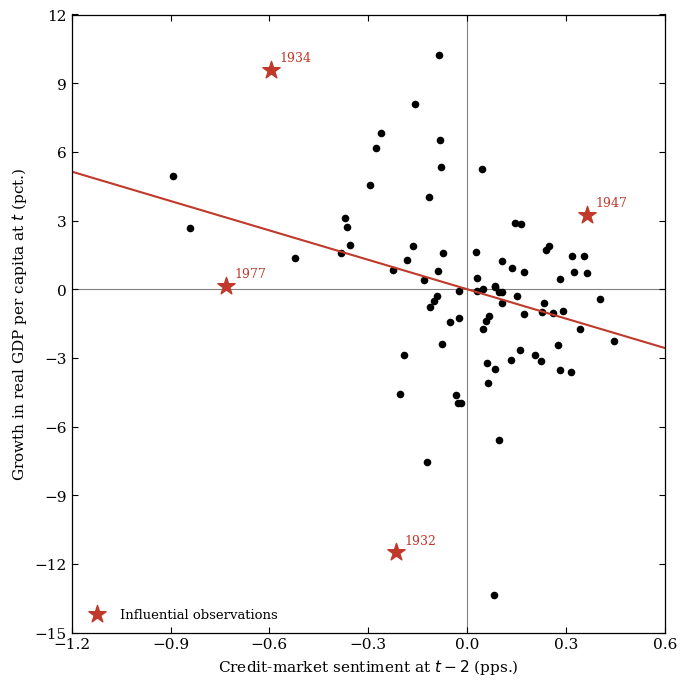

Aaa-Treasury spread


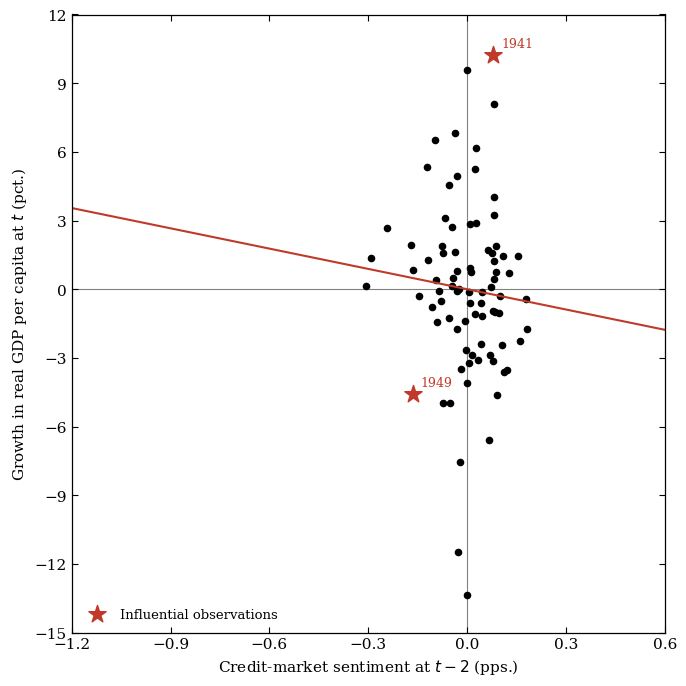

In [11]:
fig2_baa = f2.plot_figure_2(df2_baa, REP_START, REP_END)
print("Baa-Treasury spread")
plt.show()
fig2_aaa = f2.plot_figure_2(df2_aaa, REP_START, REP_END)
print("Aaa-Treasury spread")
plt.show()

The difference is visually clear. The Baa scatter (left/top) spreads
across nearly the full $[-1.2, 0.6]$ x-axis range while the Aaa scatter (right/bottom) is compressed into
roughly $[-0.3, 0.3]$. **The Aaa-based sentiment simply never gets as extreme**
because (as Figure I showed) the underlying Aaa spread itself never moved as
much, even in 1932-34. The fitted line is correspondingly flatter, and the
influential-observations set is completely different:

In [12]:
res_baa1 = res2_baa_rep["col1"]
res_aaa1 = res2_aaa_rep["col1"]
infl_baa = sorted(f2.find_influential(res_baa1, "d_s_hat"))
infl_aaa = sorted(f2.find_influential(res_aaa1, "d_s_hat"))

print(
    f"Baa fitted slope: {res_baa1.params['d_s_hat']:.3f}   influential years: {infl_baa}"
)
print(
    f"Aaa fitted slope: {res_aaa1.params['d_s_hat']:.3f}   influential years: {infl_aaa}"
)

Baa fitted slope: -4.281   influential years: [1932, 1934, 1947, 1977]
Aaa fitted slope: -2.956   influential years: [1941, 1949]


Baa's influential years (1932, 1934, 1947, 1977) are dominated by the two
biggest credit-cycle episodes in the sample. Aaa's influential years (1941
and 1949) are unrelated to either the Depression or any other major credit
crisis; they're just the two points that happen to sit furthest from Aaa's
own fitted line. There's no overlap at all
between the two sets. That's a concrete illustration of the same point
Figure I made visually: Baa and Aaa aren't measuring small variations on the
same signal, they're picking up meaningfully different information.

## Summary: Does the Rating Choice Matter?

| Exhibit | What changes, Baa → Aaa | Verdict |
|---|---|---|
| Figure I | Level and volatility both fall by roughly half and the Depression-era spike almost disappears | **Materially different series**, not a scaled-down copy |
| Table I | Same univariate point estimate but a much noisier fit  | **Weaker, noisier growth signal** |
| Table II | Every second-step coefficient shrinks 25-40% and the high-yield-share auxiliary coefficient is roughly halved | **Weaker at every stage of the two-step construction** |
| Figure II | Sentiment values compress into a much narrower range, fitted slope flattens and the influential years are completely different | **Different observations drive the (weaker) relationship** |

Across every exhibit, swapping Aaa in for Baa doesn't wipe out the paper's
result as the sign stays negative and several specifications remain
statistically significant. However, this does consistently weaken the results.

That's a meaningful robustness result. The paper's choice of Baa
is not interchangeable with "any corporate-Treasury spread." The paper's own
Section III.C makes an analogous point about credit-market sentiment being
distinct from stock-market sentiment (Table II, columns (1) vs. (2)). This extension shows the same kind of segmentation
within the credit market itself - sentiment concentrated near the
investment-grade/junk boundary carries real forecasting power for the
business cycle, and that power fades, but does not vanish, as we move toward
the safest end of the credit spectrum.